### Lab Manual 1

Defining and displaying state vectors

Qiskit uses the Python programming language, Qiskit specifically it may be helpful to very brieful discuss matrix and vector computations in Python

In Python, matrix and vector computations can be performed using the array class from the NumPy library (which includes many additional components for numerical computation)

Here is an example of a code cell that defines 2 vectors, ket0 and ket1, corresponding to the qubit state vector |0> and |1> and displayes their average

We can also use array to create matrices that represent operations

Matrix multiplication (including matrix-vector multiplication as a special case) can be performed using the `matmul` function from NumPy

In [2]:
from numpy import array

ket0 = array([1, 0])
ket1 = array([0, 1])

display(ket0 / 2 + ket1 / 2)

array([0.5, 0.5])

In [3]:
M1 = array([[1, 1], [0, 0]])
M2 = array([[1, 1], [1, 0]])

M1 / 2 + M2 / 2

array([[1. , 1. ],
       [0.5, 0. ]])

In [4]:
from numpy import matmul

display(matmul(M1, ket1))
display(matmul(M1, M2))
display(matmul(M2, M1))

array([1, 0])

array([[2, 1],
       [0, 0]])

array([[1, 1],
       [1, 1]])

Qiskit's State vector class provides functionality for defining and manipulating quantum state vectors

The following code cell imports the State vector class and defines a few vectors using it

(Note that we need the sqrt function from the NumPy library to compute the square roots for the vector u)

In [5]:
from qiskit.quantum_info import  Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([1 + 2.0 / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

print("State vectors u, v, and w have been defined")

State vectors u, v, and w have been defined


The State vecotr class provides a draw method for displaying state vectors, including latex and text options for diNerent visualizations, as this code cell demonstrates

The State vector class also includes this is valid method, which checks to see if a given vector is a valid quantum state vector (i.e., that it has Euclidean norm equal to 1)

In [6]:
display(u.draw("latex"))
display(u.draw("text"))

<IPython.core.display.Latex object>

[0.70710678+0.j,0.70710678+0.j]

In [7]:
display(u.is_valid())
display(w.is_valid())

True

False

Measurements of quantum states can be simulated in Qiskit, using the measure method from the State vector class

Running the measure method simulates a standard basis measurement

It returns the result of that measurement, plus the new quantum state of our system after the measurement

Measurement outcomes are probabilistic, so the same method can return diNerent results

Try running the cell a few times to see this

As an aside, State vector will throw an error if the measure method is applied to an invalid quantum state vector

In [8]:
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
v.draw("latex")

<IPython.core.display.Latex object>

In [9]:
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
v.draw("latex")
v.measure()

(np.str_('0'),
 Statevector([0.4472136+0.89442719j, 0.       +0.j        ],
             dims=(2,)))

State vector also comes with a sample counts method that allows for the simulation of any number of measurements on the system

For example, the following cell shows the outcomes of measuring the vector v 1000 times, which (with high probability) results in the outcome 0 approximately 5 out of every 9 times (or about 556 of 1000 trials)

The cell also demonstrates the plot histogram function for visualising the results

Running the cell multiple times and trying diNerent numbers of samples in place of 1000 may be helpful for developing some intuition for how the number of trials influences the estimated probabilities

{np.str_('0'): np.int64(524), np.str_('1'): np.int64(476)}

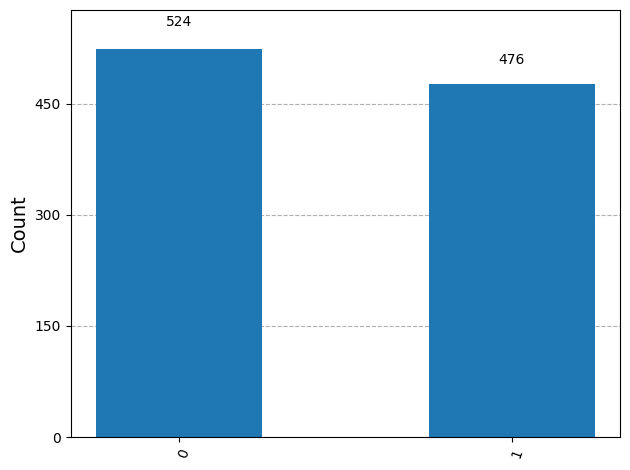

In [10]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
display(statistics)
plot_histogram(statistics)

---

### Lab 2

Performing operations with Operator and State vector

Unitary operations can be defined and performed on state vectors in Qiskit using the Operator class

In [11]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from numpy import sqrt

X = Operator([[0, 1], [1, 0]])
Y = Operator([[0, -1.0j], [1.0j, 0]])
Z = Operator([[1, 0], [0, -1]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(Z)

display(v.draw("text"))
display(v.draw("latex"))

[ 0.85355339+0.35355339j,-0.35355339+0.14644661j]

<IPython.core.display.Latex object>

Quantum Circuits

Qiskit's Quantum Circuit Class

In particular, we may define a quantum circuit (which in this case will simply be a sequence of unitary operations performed on a single qubit) as follows

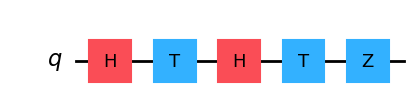

In [12]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.t(0)
circuit.z(0)

display(circuit.draw(output='mpl'))

The operations are applied sequentially, starting on the left and ending on the right in the figure

Let us first intialise a starting quantum state vector and then evolve that state according to the sequence of operations

Finally, let's simulate the result of running the experiment (i.e., preparing the state |0> applying the sequence of operations represented by the circuit, and measuring) 4000 times

In [13]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
v.draw("text")

[ 0.85355339+0.35355339j,-0.35355339+0.14644661j]

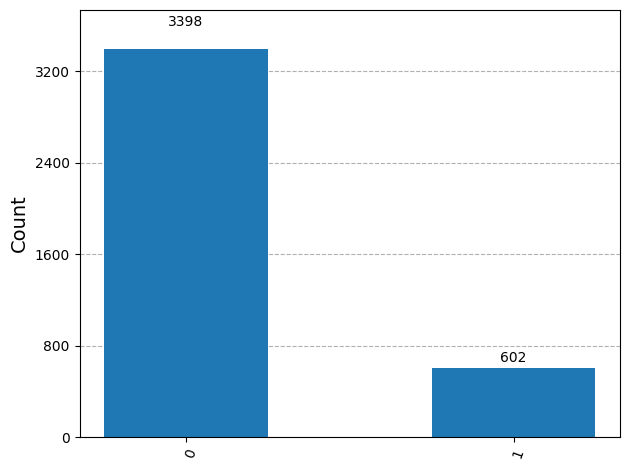

In [14]:
from qiskit.visualization import plot_histogram
statistics = v.sample_counts(4000)
plot_histogram(statistics)

---

### Lab 3

In [15]:
from qiskit.quantum_info import Statevector, Operator
from numpy import sqrt

Tensor Products

The State vector class has a tensor method which returns the tensor product of itself and another State vector

For example, below we create 2 state vectors representing |0> and |1>, and use the tensor method to create a new vector, |0> ⊗ ∣1>

In [16]:
zero, one = Statevector.from_label("0"), Statevector.from_label("1")
zero.tensor(one).draw("latex")

<IPython.core.display.Latex object>

In another example, below, we create state vectors representing the |+> and 1/√2 (|0> + i |1>) states, and combine them to create a new state vector

We'll assign this new vector the variable `psi`

In [17]:
plus = Statevector.from_label("+")
i_state = Statevector([1 / sqrt(2), 1j / sqrt(2)])
psi = plus.tensor(i_state)

psi.draw("latex")

<IPython.core.display.Latex object>

The Operator class also has a tensor method

In the example below, we create the X and I gates and display their tensor product

In [18]:
X = Operator([[0, 1], [1, 0]])
I = Operator([[1, 0], [0, 1]])

X.tensor(I)

Operator([[0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


We can treat these compound states and operations as we did single systems in the previous lesson

For example, in the cell below we calculate - (I⊗X)∣ψ⟩

For the state psi we defined above

(The ^ operator tensors matrices together)

In [19]:
psi.evolve(I ^ X).draw("latex")

<IPython.core.display.Latex object>

Below, we create a CX operator and calculate CX∣ψ⟩

In [20]:
CX = Operator(
    [
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 0 ,1, 0]
    ]
)

psi.evolve(CX).draw("latex")

<IPython.core.display.Latex object>

In the previous lab, we used the measure method to simulate a measurement of the quantum state vector

This method returns 2 items: the simulated measurement result, and the new State vector given this measurement

By default, measure measures all qubits in the state vector, but we can provide a list of integers to only measure the qubits at those indices

To demonstrate, the cell below creates the state 

W = 1/√3 (|001> + |010> + |100>)

In [21]:
W = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / sqrt(3))
W.draw("latex")

<IPython.core.display.Latex object>

The cell below simulates a measurement on the rightmost qubit (which has index 0)

The other 2 qubits are not measured

In [23]:
result, new_sv = W.measure([0]) # measure qubit 0
print(f"Measured: {result}\nState after measurement:")
new_sv.draw("latex")

Measured: 0
State after measurement:


<IPython.core.display.Latex object>

---

### Lab 4

Quantum circuits

In the quantum circuit model, wires represent qubits and gates represent operations acting on these qubits

We'll focus for now on operations we've encountered so far, namely unitary operations and standard basis measurements

As we learn about other sort of quantum operations and measurements, we'll enhance our model accordingly

In the circuit, we have a single qubit named X, which is represented by the horizontal line, and a sequence of gates representing unitary operations on this qubit

Just like in the example above, the flow of information goes from left to right - so the first operation performed is a Hadamard, the second is an S operation, the third is another Hadamard, and the final operation is a T operation

Applying the entire circuit therefore applies the composition of these operations, THSH, to the qubit X

Sometimes we wish to explicitly indicate the input or output states to a circuit

For example, if we apply the operation TSHS to the state |0>, we obtain the state (1 + i)/√2 |0> + 1/√2 |1>

Quantum circuits often have all qubits initialised to |0>, as we have in this case, but there are also cases where we wish to set the input qubits to different states

Now let's see how we can specify this circuit in Qiskit, beginning with the imports needed for the current section

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer.primitives import Sampler
from qiskit.visualization import plot_histogram

To begin, we can create the circuit as follows, by sequentially adding gates from left to right

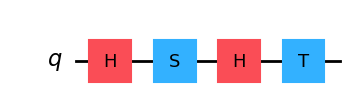

In [5]:
circuit = QuantumCircuit(1)

circuit.h(0)
circuit.s(0)
circuit.h(0)
circuit.t(0)

display(circuit.draw(output='mpl'))

The default names for Qiskit are q0, q1, q2, etc. and when there is just a single qubit like in our example, the default name is q rather than q0

If we wish to choose our own name we can do this using the Quantum Register class like this:

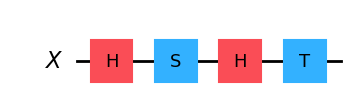

In [8]:
X = QuantumRegister(1, "X")
circuit = QuantumCircuit(X)

circuit.h(X)
circuit.s(X)
circuit.h(X)
circuit.t(X)

display(circuit.draw(output='mpl'))

In this circuit we have a Hadamard gate and a controlled-NOT gate on 2 qubits X and Y, just like in the previous example

We also have 2 classical bits, AA and BB, as well as 2 measurement gates

The meausrement gates represent standard basis measurements: the qubits are changed into their post-measurement states, while the measurement outcomes are overwritten onto the classical bits to which the arrows point

Here is an implementation of this circuit using Qiskit:

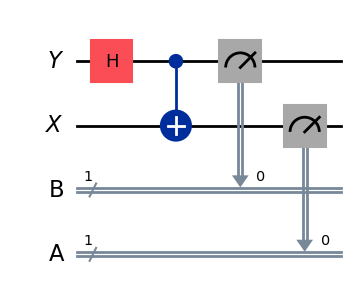

In [9]:
X = QuantumRegister(1, "X")
Y = QuantumRegister(1, "Y")
A = ClassicalRegister(1, "A")
B = ClassicalRegister(1, "B")

circuit = QuantumCircuit(Y, X, B, A)
circuit.h(Y)
circuit.cx(Y, X)
circuit.measure(Y, B)
circuit.measure(X, A)

display(circuit.draw(output='mpl'))

The circuit can be simulated using the Sampler primitive

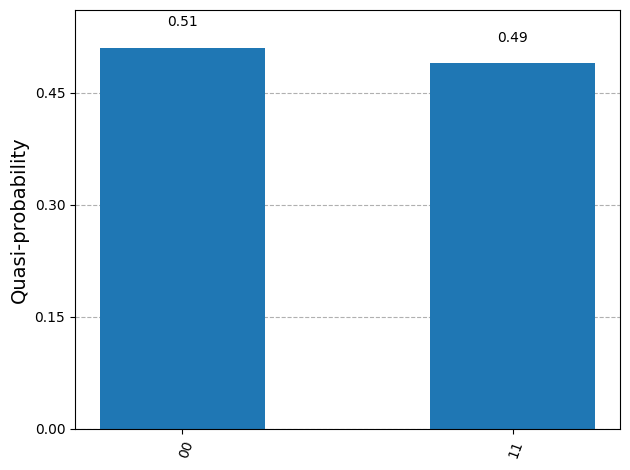

In [51]:
results = Sampler().run(circuit).result()
statistics = results.quasi_dists[0].binary_probabilities()
display(plot_histogram(statistics))

---